In [2]:
import math
import gdsfactory as gf
from gdsfactory import Component
from gdsfactory.typings import LayerSpec, LayerSpecs
import gdsfactory as gf
from gdsfactory.components import via_stack

from ihp import PDK

PDK.activate()

In [3]:
def secondary_inductor(
    width: float = 3.0,
    space: float = 3.1,
    diameter: float = 50.0,
    layer_metal: LayerSpec = "TopMetal2drawing",
    layer_metal_name: str = "TopMetal2",
    layer_jumper: LayerSpec = "TopMetal1drawing",
    layer_jumper_name: str = "TopMetal1",
    via_size: float = 1.5,
) -> Component:
    w = width
    s = space
    d = diameter

    r = d / 2 + s
    octagon_center_y = 3 * r
    pi_over_4 = math.radians(45)

    path_points = [(+space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2))]
    for i in range(-2, 6):
        angle = i * pi_over_4 + pi_over_4 / 2
        r = d / 2 + s
        x = r * math.cos(angle)
        y = r * math.sin(angle) + octagon_center_y
        path_points.append((x, y))
    path_points.append((-space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2)))

    gap_y = octagon_center_y - r * math.cos(pi_over_4 / 2)

    path = gf.Path(path_points)
    c = gf.path.extrude(path, layer=layer_metal, width=w)

    length = 2 * r + s

    lead1 = c << gf.components.rectangle(size=(s, length), layer=layer_jumper)
    lead1.move((-s - s / 2, 0))
    c.add_port(name="P1", center=(-s, s), width=s, orientation=270, layer=layer_jumper)

    lead2 = c << gf.components.rectangle(size=(s, length), layer=layer_jumper)
    lead2.move((s - s / 2, 0))
    c.add_port(name="P2", center=(s, s), width=s, orientation=270, layer=layer_jumper)

    via_stack_component = gf.get_component(
        "via_stack",
        bottom_layer=layer_jumper_name,
        top_layer=layer_metal_name,
        size=(via_size, via_size),
        vn_columns=1,
        vn_rows=1,
    )
    junction1 = c.add_ref(via_stack_component)
    junction1.move(junction1.center, (-space, gap_y))
    junction2 = c.add_ref(via_stack_component)
    junction2.move(junction2.center, (space, gap_y))

    c.flatten()
    return c

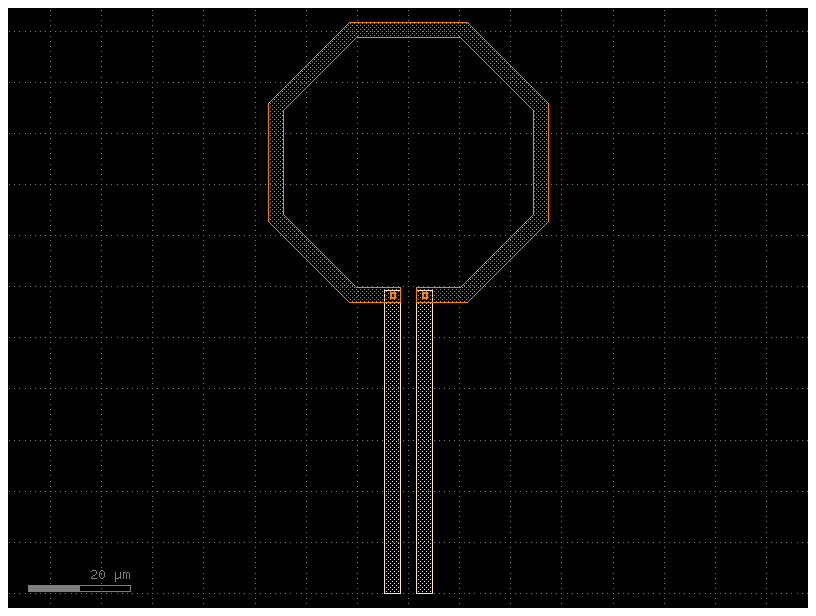

In [4]:
secondary_inductor().plot()

In [5]:
@gf.cell
def transformer_concentric(
    width_primary: float = 3.0,
    width_secondary: float = 3.0,
    space: float = 3.1,
    coupling_gap: float = 4.0,
    diameter_outer: float = 80.0,
    layer: LayerSpec = "TopMetal2drawing",
    layer_name: str = "TopMetal2",
    jumper_layer: LayerSpec = "TopMetal1drawing",
    jumper_bottom_layer_name: str = "TopMetal1",
    via_size: float | None = None,
    layer_inductor: LayerSpec = "INDdrawing",
    layers_no_fill: LayerSpecs = ("NoMetFillerdrawing",),
) -> Component:
    """Concentric, coplanar 1:1 transformer (single-turn coils).

    Primary: standard gf.components.inductor(), outer ring, on `layer`.
    Secondary: same octagonal spiral, inner ring, but its leads are drawn
    on `jumper_layer` (TopMetal1) instead of `layer`, so they pass
    underneath the primary ring without colliding. A via_stack connects
    each lead to the coil body right where they meet, then the lead runs
    on jumper_layer straight out past the primary's outer edge.

    Returns:
        Component with ports P1, P2 (primary, on layer) and
        S1, S2 (secondary, on jumper_layer).
    """
    c = gf.Component()
    via_size = via_size or width_secondary

    # Primary coil (outer ring), standard inductor
    primary = gf.components.inductor(
        width=width_primary,
        space=space,
        diameter=diameter_outer,
        turns=1,
        layer_metal=layer,
        layer_inductor=layer_inductor,
        layer_metal_pin=layer,
        layers_no_fill=layers_no_fill,
    )
    prim_ref = c.add_ref(primary)
    cx, cy = prim_ref.center
    prim_ref.move((-cx, -cy))

    # Compute inner diameter for secondary
    diameter_secondary = diameter_outer - 2 * (width_primary + space) - 2 * coupling_gap

    # Secondary coil geometry
    w = width_secondary
    s = space
    d = diameter_secondary

    r = d / 2 + s
    octagon_center_y = 3 * r
    pi_over_4 = math.radians(45)

    path_points = [(+space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2))]
    for i in range(-2, 6):
        angle = i * pi_over_4 + pi_over_4 / 2
        r = d / 2 + s
        x = r * math.cos(angle)
        y = r * math.sin(angle) + octagon_center_y
        path_points.append((x, y))
    path_points.append((-space / 2, octagon_center_y - r * math.cos(pi_over_4 / 2)))

    # This is the actual gap where the coil is open — the real
    # junction point between the coil body and each lead
    gap_y = octagon_center_y - r * math.cos(pi_over_4 / 2)

    path = gf.Path(path_points)
    secondary = gf.path.extrude(path, layer=layer, width=w)

    length = 2 * r + s

    lead1 = secondary << gf.components.rectangle(size=(s, length), layer=jumper_layer)
    lead1.move((-s - s / 2, 0))
    lead2 = secondary << gf.components.rectangle(size=(s, length), layer=jumper_layer)
    lead2.move((s - s / 2, 0))

    # Connect coil body (layer) to each lead (jumper_layer)
    via_stack_component = gf.get_component(
        "via_stack",
        bottom_layer=jumper_bottom_layer_name,
        top_layer=layer_name,
        size=(via_size, via_size),
    )
    junction1 = secondary.add_ref(via_stack_component)
    junction1.move(junction1.center, (-space, gap_y))
    junction2 = secondary.add_ref(via_stack_component)
    junction2.move(junction2.center, (space, gap_y))

    # External ports on jumper_layer
    secondary.add_port(
        name="S1", center=(-s, s), width=s, orientation=90, layer=jumper_layer
    )
    secondary.add_port(
        name="S2", center=(s, s), width=s, orientation=90, layer=jumper_layer
    )

    # IND marker layer
    outer_polygon_pts = []
    for i in range(8):
        r_outer = (d / 2 + length) / (math.cos(pi_over_4 / 2))
        angle = i * pi_over_4 + pi_over_4 / 2
        x = r_outer * math.cos(angle)
        y = r_outer * math.sin(angle) + octagon_center_y
        outer_polygon_pts.append((x, y))
    secondary.add_polygon(points=outer_polygon_pts, layer=layer_inductor)

    sec_ref = c.add_ref(secondary)
    sec_ref.rotate(180)
    cx, cy = sec_ref.center
    sec_ref.move((-cx, -cy))

    # Expose all 4 ports
    c.add_port(name="P1", port=prim_ref.ports["P1"])
    c.add_port(name="P2", port=prim_ref.ports["P2"])
    c.add_port(name="S1", port=sec_ref.ports["S1"])
    c.add_port(name="S2", port=sec_ref.ports["S2"])

    c.flatten()
    return c

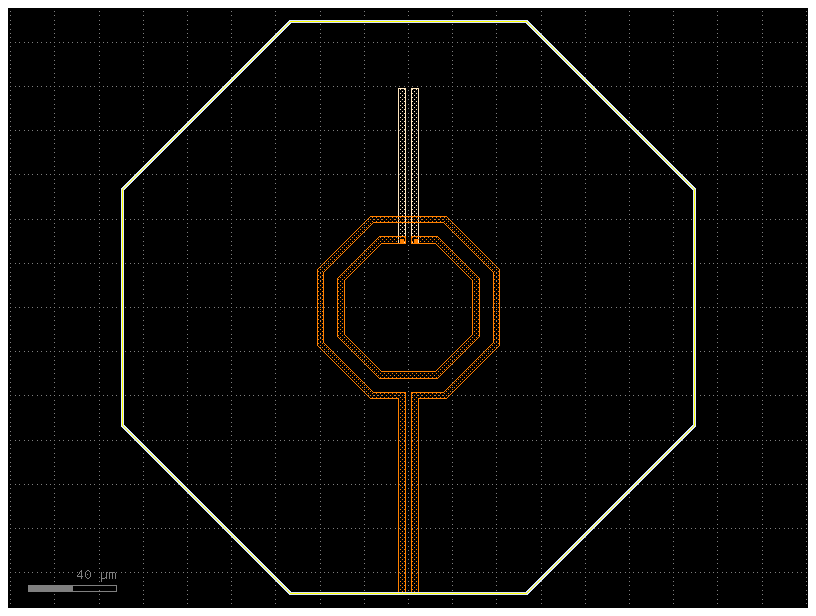

In [6]:
c = transformer_concentric()
c.plot()

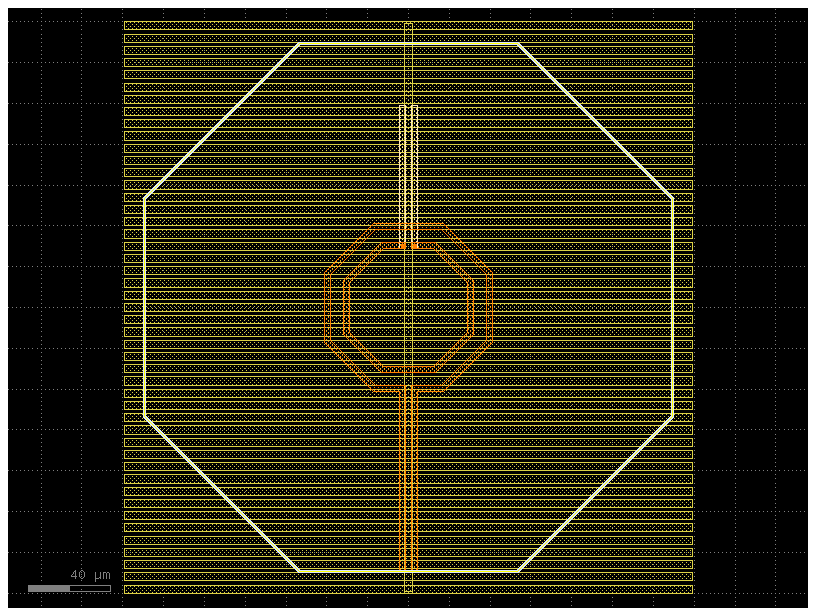

In [7]:
def add_pgs_to_transformer(
    c: gf.Component,
    margin: float = 5.0,
    w: float = 2.0,
    s: float = 2.0,
    layer="Metal5drawing",
):
    bbox = c.bbox()

    # Calculate center manually
    cx = (bbox.left + bbox.right) / 2
    cy = (bbox.bottom + bbox.top) / 2

    # Shield boundaries (Padded)
    xmin, xmax = bbox.left - margin, bbox.right + margin
    ymin, ymax = bbox.bottom - margin, bbox.top + margin

    # 1. Central vertical spine
    c.add_polygon(
        [
            (-w / 2 + cx, ymin),
            (-w / 2 + cx, ymax),
            (w / 2 + cx, ymax),
            (w / 2 + cx, ymin),
        ],
        layer=layer,
    )

    # 2. Horizontal fingers
    pitch = w + s
    total_height = ymax - ymin
    num_fingers = math.floor(total_height / pitch)

    for i in range(-num_fingers // 2, num_fingers // 2 + 1):
        yc = cy + (i * pitch)
        c.add_polygon(
            [
                (xmin, yc - w / 2),
                (xmin, yc + w / 2),
                (xmax, yc + w / 2),
                (xmax, yc - w / 2),
            ],
            layer=layer,
        )


cc = c.copy()
add_pgs_to_transformer(cc, margin=10.0, w=4.0, s=2.0)

cc.plot()

In [8]:
from gsim.palace import DrivenSim

sim = DrivenSim()
sim.set_output_dir("./palace-sim-transformer-concentric")
sim.set_geometry(cc)
sim.set_stack(substrate_thickness=180.0, include_substrate=True)

# P1, P2 -> primary coil, on TopMetal2
sim.add_port(
    "P1", from_layer="metal5", to_layer="topmetal2", geometry="via", excited=True
)
sim.add_port(
    "P2", from_layer="metal5", to_layer="topmetal2", geometry="via", excited=True
)

# S1, S" -> secondary coil, same layer as primary
sim.add_port(
    "S1", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True
)

sim.add_port(
    "S2", from_layer="metal5", to_layer="topmetal1", geometry="via", excited=True
)

sim.set_driven(fmin=10e9, fmax=100e9, num_points=50)
print(sim.validate_config())

Validation: PASSED


In [9]:
# Generate mesh (presets: "coarse", "default", "fine")
sim.set_airbox(margin_x=50, margin_y=50, z_above=50, z_below=5)
sim.mesh(preset="default", refined_mesh_size=3)
sim.write_config()

Small conductor feature detected (2.000 um) may be under-resolved by refined_mesh_size=5.000 um. Pass auto_size=True to scale the mesh down.


Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            
Info    : Reading 'palace-sim-transformer-concentric/palace.msh'...
Info    : 45594 nodes
Info    : 341778 elements
Info    : Done reading 'palace-sim-transformer-concentric/palace.msh'                                            


PosixPath('palace-sim-transformer-concentric/config.json')

In [10]:
sim.plot_mesh(show_groups=["metal", "P", "via"])

Widget(value='<iframe src="http://localhost:46669/index.html?ui=P_0x7a5ae81f36b0_0&reconnect=auto" class="pyvi…

In [12]:
results = sim.run(parent_dir="./palace-sim-transformer-concentric")

  palace-44848cb5  completed  17m 50s
Extracting results.tar.gz...
Downloaded 10 files to palace-sim-transformer-concentric/sim-data-palace-44848cb5


In [13]:
# results = sim.run_local(use_apptainer=False,palace_executable="~/palace/build/bin/palace",num_processes=4)

In [14]:
results.plot_interactive()

Port mapping: Port 1: P1, Port 2: P2, Port 3: S1, Port 4: S2


Detected 4 ports: ['P1', 'P2', 'S1', 'S2']


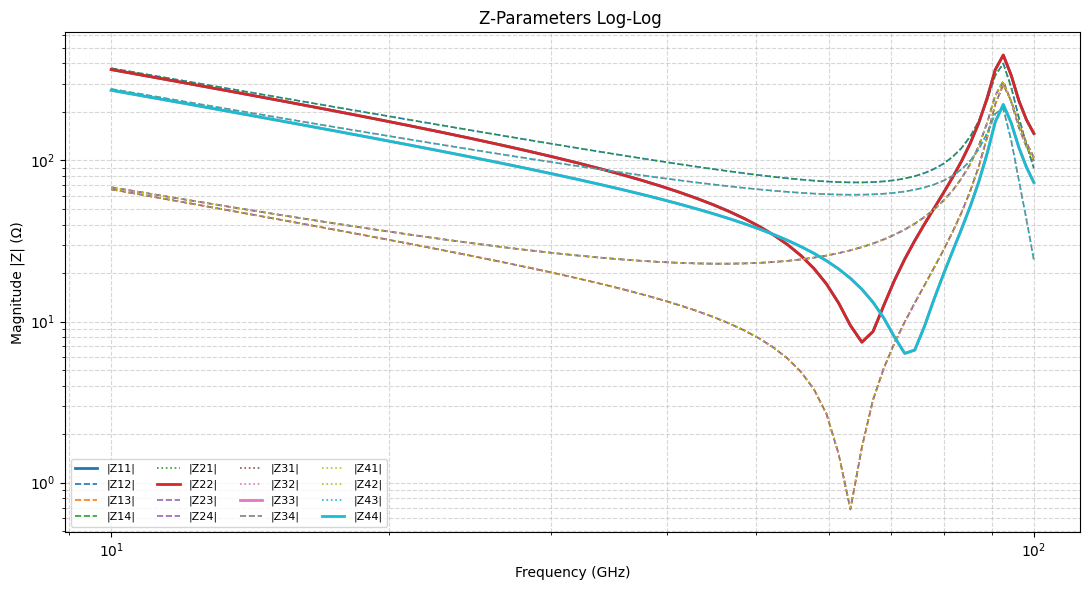

In [15]:
from s_to_z_parameters import plot_z_parameters, plot_differential_z_parameters

Z, Y, f = plot_z_parameters(results, freq_unit="GHz")

In [18]:
Z_mm, f = plot_differential_z_parameters(results, freq_unit="GHz")

Error converting to mixed-mode: object does not have attribute s_2_mixed


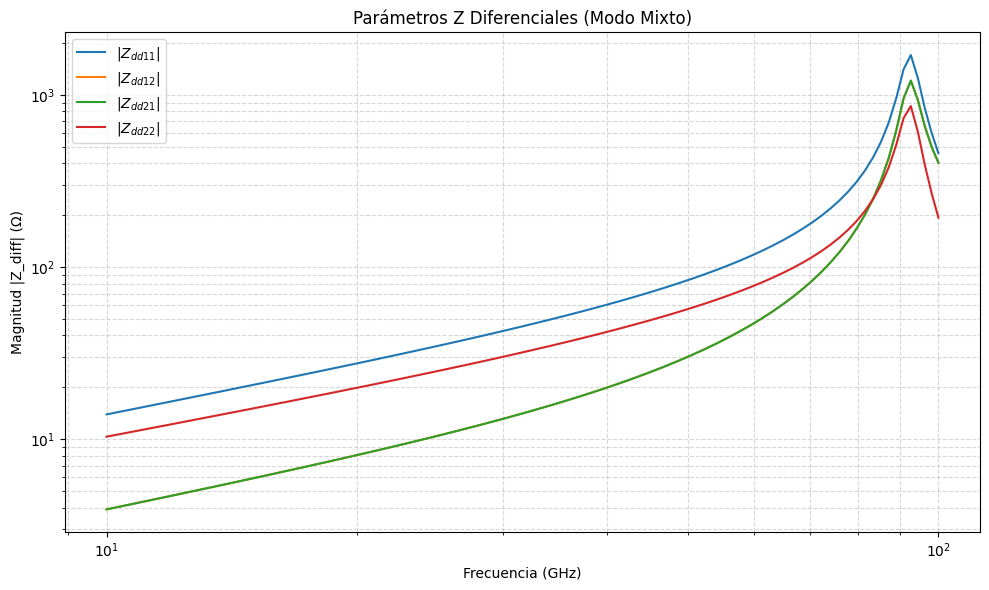

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import skrf as rf

# ── 1. Preparación de datos ──────────────────────────────────────────────
freq_scale = 1e9  # Asumiendo GHz
f = results.freq * freq_scale
ports = results.port_names
n = len(ports)

# Construcción de la matriz S desde los resultados
S = np.zeros((len(f), n, n), dtype=complex)
for i, pi in enumerate(ports):
    for j, pj in enumerate(ports):
        S[:, i, j] = results[(pi, pj)].complex

# Crear red y convertir a modo mixto
ntwk = rf.Network(f=f, s=S, f_unit="hz")
ntwk.se2gmm(p=int(n / 2))
Z_mm = ntwk.z

# ── 2. Graficación (Modo Diferencial DD) ──────────────────────────────────
plt.figure(figsize=(10, 6))

# Graficamos la submatriz diferencial (Zdd, que ocupa el cuadrante superior izquierdo)
num_diff = int(n / 2)
for i in range(num_diff):
    for j in range(num_diff):
        plt.plot(f / 1e9, np.abs(Z_mm[:, i, j]), label=f"$|Z_{{dd{i + 1}{j + 1}}}|$")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Frecuencia (GHz)")
plt.ylabel("Magnitud |Z_diff| (Ω)")
plt.title("Parámetros Z Diferenciales (Modo Mixto)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()